In [27]:
from itertools import *
import seaborn as sea
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ase import Atoms
from ase.visualize import view
from random import sample,seed
from shape_proj_util.geo_tools.geometry import *
from ase.io.xyz import write_xyz
from scipy.spatial.distance import cdist
import random
from tqdm.auto import tqdm
from scipy.spatial import ConvexHull,QhullError
from scipy.spatial import cKDTree


In [3]:
#a: lattice constant
#x,y,z are how many times lattice extends along this direction
#x,y,z must large than 1
def fccbasis(a):
    fcc = [[0,0.5*a,0.5*a],[0.5*a,0,0.5*a],[0.5*a,0.5*a,0],[0,0,0],\
                    [0,0,a],[0,a,0],[a,0,0],[a,a,0],\
                    [0,a,a],[a,0,a],[a,a,a],[a,0.5*a,0.5*a],\
                    [0.5*a,a,0.5*a],[0.5*a,0.5*a,a]]
    return np.array(fcc)

#lattice is an array containing coordinates in fcc
def extendfcc(lattice,a,x,y,z):
    lattice_extend = []
    for i in range(0,x):
        for j in range(0,y):
            for k in range(0,z):
                for o in range(0,len(lattice)):
                    if not lattice_extend.__contains__([lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]):
                        lattice_extend.extend([[lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]])
    return np.array(lattice_extend)

In [109]:
def empty_lattice(lc,n1,n2,n3):
    """
    Generate a fcc lattice by given lattice constant and superlattice parameters: n1,n2,n3.
    The constructed lattice is centered at (0,0,0), and the coordinates are reordered by the 
    atom to center distance.
    @param lc: lattice constant
    @param n1: superlattice parameter: number of cells on x direction
    @param n2: superlattice parameter: number of cells on y direction
    @param n3: superlattice parameter: number of cells on z direction
    @param mid_position: the position of the center of the lattice, if None, the center of the lattice is set to (0,0,0)
    return: ordered lattice, mid_position
    """

    # lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    mid_position=np.mean(lattice,axis=0)
    # lattice=np.round(lattice-mid_position,6)
    closest_index=np.where(np.all(np.isclose(mid_position,lattice,rtol=lc/(2*np.sqrt(2))),axis=1))[0][0]
    lattice=lattice-lattice[closest_index]
    return order_pos(lattice)

def order_pos(lattice,mid_position=None):
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)

def particles_encode_gen_no_oblate(lc,lattice_big,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    # transfer points to the big lattice
    indices=[]
    # genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(
            np.where(
                np.all(np.isclose(lattice_big, lattice_big[i], rtol=1e-3), axis=1)
            )[0]
        )
    return lattice_big[indices]
# generate random lattice with random n1,n2,n3 of the superlattice parimeters, and random numbers of atoms in the lattice.
def particles_encode_gen(lc,lattice_big,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        # assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    # min_num_points=num_atoms
    
    # print(f"length={np.mean(lattice_big,axis=0)}")
    # times=random.randint(1,3)
    # the extreme case is that the particle has only one layer of unit cells, which has the dimension: np.sqrt(n_max**3)*np.sqrt(n_max**3)*1
    n1=random.randint(1,np.floor(np.sqrt(n_max**3)))
    n2=n1
    n3=random.randint(1,n1)
    lattice=empty_lattice(lc,n1,n2,n3)
    num_points=len(lattice)
    #this is too strong
    while num_points<num_atoms*2 or n1*n2*n3>n_max**3:
        n1=random.randint(1,np.floor(np.sqrt(n_max**3)))
        n2=n1
        n3=random.randint(1,n1)
        lattice=empty_lattice(lc,n1,n2,n3)
        num_points=len(lattice)
        # print((num_points,n1,n2,n3,num_atoms))
    # print(f"length={np.mean(lattice,axis=0)}")
    # transfer points to the big lattice
    indices=[]
    # genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice[i],rtol=1e-3),axis=1))[0])
    return lattice_big[indices]


def ini_population(lc,population_size,lattice_big,num_atoms=None,max_num_atoms=None):
    generations=[]
    n=0
    while n<population_size:
        particle=particles_encode_gen(lc,lattice_big=lattice_big,num_atoms=num_atoms,max_num_atoms=max_num_atoms)
        generations.append(particle)
        n+=1
    return generations

def fitness(particle,descriptors:dict):
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    cluster_descriptors=descriptor_table(atom)
    true_dis=np.array([descriptors[k] for k in descriptors.keys()])
    # print(true_dis)
    pred_dis=np.array([cluster_descriptors[k] for k in descriptors.keys()])
    # print(pred_dis)
    #MSE
    #np.sum((true_dis-pred_dis)**2)
    if cluster_descriptors["flattening_moment"]==0:
        sim=100
    else:    
        sim=np.max(np.abs(pred_dis/true_dis-1))
    return sim,pred_dis

            
def parents(population,fitness_values,tol=1e5):
    fitness_values=np.array(fitness_values)
    ranking=ranking_fitness(fitness_values)
    prob=normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current=0
    index=0
    # for i in range(len(population)):
    while index<tol:
        i=random.randint(0,len(population)-1)
        index+=1
        if random.uniform(0,1)<=prob[i]:
            return list(population[i])
        if index==tol:
            raise Exception("exceed the maximum try times!")
        
        
def ranking_fitness(fitness_values):
    fitness_ranking=np.zeros(len(fitness_values))
    fitness_dict=Counter(fitness_values)
    fitness_ordered=sorted(fitness_dict.keys(),reverse=False)
    rank=1
    for i in range(len(fitness_ordered)):
        indices=np.where(np.array(fitness_values)==fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j]=rank
        rank+=1
    return fitness_ranking
def probability_selection(fitness_ranking):
    R=len(fitness_ranking)
    lamb=np.log(10)/(max(fitness_ranking)-min(fitness_ranking))
    # print(lamb)
    z=np.array([np.exp(-lamb*r) for r in fitness_ranking])
    z_sum=np.sum(z)
    return z/z_sum 
def normalized_p(fitness_ranking):
    p=probability_selection(fitness_ranking)
    return (p-np.min(p))/(np.max(p)-np.min(p))

def atom_cut_up_down_center(particle,theta,phi,lc):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(particle)
    particle=np.array(particle)
    if len(particle)<5:
        print("Warning particle is less than 5 atoms")
        return particle,particle
    center=np.mean(particle,axis=0)
    closest_index=np.where(np.all(np.isclose(center,particle,rtol=lc/(1.8*np.sqrt(2))),axis=1))[0][0]
    particle_shift=particle-particle[closest_index]
    center=np.mean(particle_shift,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_up_particle=[]
    trancate_down_particle=[]
    for pos in particle_shift:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=-lc/np.sqrt(2):
            trancate_up_particle.append([pos[0],pos[1],pos[2]])
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=lc/np.sqrt(2):
            trancate_down_particle.append([pos[0],pos[1],pos[2]])
    # print(len(trancate_up_particle))
    # print(len(trancate_down_particle))
    return np.array(trancate_up_particle),np.array(trancate_down_particle)


def atom_trancate_center(particle,theta,phi):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    
    # print(f"1={len(genome_recon)}")
    # print(len(particle),len(trancate_particle),len(np.where(np.array(genome_recon)==1)[0]))
    return trancate_particle
    
def atom_trancate_arbi(particle,theta,phi):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(particle)
    particle=np.array(particle)
    center_get=np.mean(particle,axis=0)
    particle_vote=particle.copy()
    if [center_get] not in particle_vote:
        np.vstack((particle_vote,center_get))
    # for i in range(len(particle)):
    #     CN1,dis=getCN_dis_Oneshell(particle,particle[i],1,thickness=0.1)
    #     if CN1==12:
    #         center_get.append(particle[i])
    # if len(center_get)!=0:
    center=random.choice(particle_vote)
    # else:
    #     return particle
    ## points with coordination numbers are 12 are considered as the center of planes for truncation.
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])  
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    # if len(trancate_particle)<5:
    #     trancate_particle=[]
    #     for pos in particle:
    #         if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
    #             trancate_particle.append([pos[0],pos[1],pos[2]])
        # print(f"len(trancate_particle)={len(trancate_particle)}")
    return trancate_particle


def crossover(lc,parent1,parent2,cross_over_rate=0.6):
    def remove_duplicates(particle,lc):
        duplicates=[]
        index_get=[]
        for i in range(len(particle)):
            index=np.where(np.isclose(cdist([particle[i]],particle)[0],0,atol=1e-2))[0]
            if len(index)>1:
                duplicates.extend(index[1:])
            if index[0] not in duplicates:
                index_get.append(index[0])
        return np.array([particle[i] for i in index_get])
    if random.random()<cross_over_rate:
        theta=random.uniform(0,np.pi)
        phi=random.uniform(0,2*np.pi)
        # parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        # parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        try:
            parent1_up,parent1_down=atom_cut_up_down_center(parent1,theta,phi,lc)
            parent2_up,parent2_down=atom_cut_up_down_center(parent2,theta,phi,lc)
        except:
            return parent1,parent2
        parent1=np.vstack((parent1_up,parent2_down))
        parent2=np.vstack((parent1_down,parent2_up))
        parent1=remove_duplicates(parent1,lc)
        parent2=remove_duplicates(parent2,lc)
        # print(parent1_up,parent2_down)
        # print(parent1_down,parent2_up)
        return parent1,parent2
    else:
        return parent1,parent2
    

def mutation(particle, lc, lattice_big, max_num_atoms, mutation_rate=0.3):
    mr = random.uniform(0, 1)
    num_atoms = len(particle)

    if mr <= mutation_rate:# / 2:
        # renum = 0
        # theta = random.uniform(0, np.pi)
        # phi = random.uniform(0, 2 * np.pi)
        # particle_update = atom_trancate_center(particle, theta, phi)
        # while len(particle_update) < 5 and renum < 5:
        #     theta = random.uniform(0, np.pi)
        #     phi = random.uniform(0, 2 * np.pi)
        #     # if renum==0:
        #     #     print("no good 1")
        #     particle_update = atom_trancate_center(particle, theta, phi)
        #     renum += 1
    # elif mr > mutation_rate / 2:# and mr <= mutation_rate * 2 / 3:
        renum = 0
        theta = random.uniform(0, np.pi)
        phi = random.uniform(0, 2 * np.pi)
        particle_update = atom_trancate_arbi(particle, theta, phi)
        while len(particle_update) < 5 and renum < 5:
            theta = random.uniform(0, np.pi)
            phi = random.uniform(0, 2 * np.pi)
            particle_update = atom_trancate_arbi(particle, theta, phi)
            renum += 1
    # elif mr > mutation_rate * 2 / 3 and mr <= mutation_rate:
    #     # 2. initialization of populations
    #     particle_update = ini_population(
    #         lc=lc,
    #         population_size=1,
    #         lattice_big=lattice_big,
    #         max_num_atoms=max_num_atoms,
    #         num_atoms=None,
    #     )[0]

    else:
        particle_update = particle
    return particle_update
def convex_particle(particle,lattice_big,lc):
    indices=[]
    try:
        hull=ConvexHull(particle)
    except QhullError:
        # print("less than 3 dimensions")
        # print(particle)
        return particle
    for points in lattice_big:
        if is_point_in_hull(points,hull,lc):
            indices.extend(np.where(np.all(np.isclose(points,lattice_big,rtol=1e-1),axis=1))[0])
    # print(len(indices))
    # print(len(particle))
    return np.array([lattice_big[i] for i in indices])

def is_point_in_hull(point,hull,lc):
    equations=hull.equations
    # print(np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0))
    return np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=lc/(2*np.sqrt(2)))
def find_most_similar(population,individual,crowding_distance=0.1):
    return np.array([min(population, key=lambda x: calculate_similarity(x, individual,crowding_distance))])[0]

def chamfer_distance(point_cloud_A, point_cloud_B):
    tree_A = cKDTree(point_cloud_A)
    tree_B = cKDTree(point_cloud_B)
    
    dist_A_to_B, _ = tree_A.query(point_cloud_B, k=1)
    dist_B_to_A, _ = tree_B.query(point_cloud_A, k=1)
    
    chamfer_dist = np.mean(dist_A_to_B) + np.mean(dist_B_to_A)
    
    return chamfer_dist

def align_point_clouds_pca(particle1, particle2):
    #align particle1 to particle2
    # Center the point clouds
    source_centered = particle1 - np.mean(particle1, axis=0)
    target_centered = particle2 - np.mean(particle2, axis=0)
    
    # Perform PCA
    source_pca = PCA(n_components=3).fit(source_centered)
    target_pca = PCA(n_components=3).fit(target_centered)
    
    # Align principal components
    R = np.dot(target_pca.components_.T, source_pca.components_)
    aligned_source = np.dot(source_centered, R.T) + np.mean(particle2, axis=0)
    
    return aligned_source
def sharing_function(ind1, ind2, niche_radius, alpha):
    distance = calculate_similarity(ind1, ind2, niche_radius)
    if distance < niche_radius:
        return 1 - (distance / niche_radius) ** alpha
    else:
        return 0


def calculate_similarity(ind1, ind2,crowding_distance=0.1):
    # atoms1 = Atoms(positions=ind1, symbols=["Pt"] * len(ind1))
    # atoms2 = Atoms(positions=in2, symbols=["Pt"] * len(in2))
    # des_atoms1 = descriptor_table(atoms1)
    # score1 = np.array(np.array([des_atoms1[k] for k in des_atoms1.keys()]))
    # des_atoms2 = descriptor_table(atoms2)
    # score2 = np.array([des_atoms2[k] for k in des_atoms2.keys()])
    # return np.mean((score1 - score2) ** 2)
    ind1=align_point_clouds_pca(ind1,ind2)
    dist=chamfer_distance(ind1,ind2)

    return dist/crowding_distance
def shared_fitness_value(individual, descriptor, population, niche_radius, alpha):
    fitnessvalue = fitness(individual,descriptor)[0]
    sharing_sum = sum(sharing_function(individual, other, niche_radius, alpha) for other in population)
    return fitnessvalue / sharing_sum
def fitness_sharing(population,descriptor,niche_radius, alpha):
    shared_fitness = []
    for individual in population:
        shared_fitness.append(shared_fitness_value(individual, descriptor, population, niche_radius, alpha))
    return shared_fitness
def genetic_algorithm(
    max_num_atoms=200,
    generations=40,
    population_size=100,
    lc=3.77,
    mutation_rate=0.3,
    cross_over_rate=0.3,
    elite_fraction=0.05,
    initial_crowding_distance=0.1,
    alpha=1,
    initial_mutation_rate=0.1,
    mutation_rate_decay=0.99,
    descriptors={"flattening_moment": 1, "atom_number": 55}
    # "CN1":6,
    # "CN2":1.5,
    # "CN3":2,
    # "CN4":5
):
    # 1. set up parameters

    print(descriptors)
    num_lattice = max_num_atoms // 2  # since one unit cell of fcc lattice has 2 atoms
    n_max = int(np.ceil(np.cbrt(num_lattice)))
    lattice_big = empty_lattice(
        lc, int(np.sqrt(n_max**3)), int(np.sqrt(n_max**3)), int(np.sqrt(n_max**3))
    )

    # 2. initialization of populations
    populations = ini_population(
        lc=lc,
        population_size=population_size,
        lattice_big=lattice_big,
        num_atoms=None,
        max_num_atoms=max_num_atoms,
    )
    # populations_ini_mute=[]
    # for i in range(len(populations)):
    #     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
    ini_population_record = populations.copy()
    fitness_record = []
    best_particle = []
    # 3. calculate fitness for populations
    fitness_values = [fitness(particle, descriptors)[0] for particle in populations]
    # print(len(fitness_values),len(populations))
    # 4. start iteration
    for generation in tqdm(range(generations)):
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        # (1). generate new populations
        new_populations = []
        fit_pop = dict()
        for i in range(len(populations)):
            fit_pop[fitness_values[i]] = populations[i]
        sorted_population = [
            sorted(fit_pop.items(), key=lambda item: item[0], reverse=False)[i][1]
            for i in range(len(fit_pop))
        ]
        # print(population_size,elite_fraction)
        num_elites = int(population_size * elite_fraction)
        elites = sorted_population[:num_elites]
        # check duplicates, if duplicates exist, then generate a new structure
        num_residual = population_size - num_elites
        n = 0
        while n != num_residual:
            # [1]. find parents from populations based on fitness values
            # print(len(populations),len(parameters),len(fitness_values))
            parent1 = parents(populations, fitness_values)
            parent2 = parents(populations, fitness_values)
            parent1 = np.array(parent1)
            parent2 = np.array(parent2)
            # fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
            # fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
            # [2]. crossover and mutation to generate offsprings
            children1, children2 = crossover(
                lc, parent1, parent2, cross_over_rate=cross_over_rate
            )

            # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
            children1 = mutation(
                children1, lc, lattice_big, max_num_atoms, mutation_rate=mutation_rate
            )
            children2 = mutation(
                children2, lc, lattice_big, max_num_atoms, mutation_rate=mutation_rate
            )
            # convex hull
            
            children1 = convex_particle(children1, lattice_big, lc)
            children2 = convex_particle(children2, lattice_big, lc)
            if len(children1) ==0 or len(children2)==0:
                    continue
            # children1=convex_particle(children1,shell,lc,max_num_atoms)
            # children2=convex_particle(children2,shell,lc,max_num_atoms)
            new_populations.extend([children1, children2])
            n += 2
            if num_residual - n == 1:
                parent1 = parents(populations, fitness_values)
                parent2 = parents(populations, fitness_values)
                parent1 = np.array(parent1)
                parent2 = np.array(parent2)
                children1, children2 = crossover(
                    lc, parent1, parent2, cross_over_rate=cross_over_rate
                )
                children1 = mutation(
                    children1,
                    lc,
                    lattice_big,
                    max_num_atoms,
                    mutation_rate=mutation_rate,
                )
                children2 = mutation(
                    children2,
                    lc,
                    lattice_big,
                    max_num_atoms,
                    mutation_rate=mutation_rate,
                )
                children1 = convex_particle(children1, lattice_big, lc)
                children2 = convex_particle(children2, lattice_big, lc)
                if len(children1) ==0 or len(children2)==0:
                    continue
                new_populations.extend([children1])
                n += 1
        new_populations.extend(elites)
        crowding_distance=initial_crowding_distance
        for child in new_populations:
            most_similar_individual = find_most_similar(populations, child, crowding_distance)
            if (
                fitness(child, descriptors)[0]
                <= fitness(most_similar_individual, descriptors)[0]
            ):
                index = 0
                for ind in populations:
                    if np.array_equal(ind, most_similar_individual):
                        break
                    index += 1
                populations.pop(index)
                populations.append(child)
        # for child in new_populations:
        #     print(f"child={populations}")
        #     most_similar_individual = find_most_similar(populations, child)
        #     # print(f"most_similar_individual={most_similar_individual.shape}")
        #     # print(f"child={child.shape}")

        #     if fitness(child,descriptors)[0] <= fitness(most_similar_individual,descriptors)[0]:

        #         populations = [ind for ind in populations if not np.array_equal(ind, most_similar_individual)]
        #         new_population2.append(child)
        #     else:
        #         new_population2.append(most_similar_individual)
        # new_population2 = new_population2[:population_size]
        # new_populations.extend(elites)
        # print(f"new_populations={len(new_populations)}")

        # (2). calculate fitness for new populations and obtain the predicted descriptors
        fitness_values = []
        predict_values = []
        for particle in populations:
            # print(f"genome={genome}")
            # fitness_cal = fitness(particle, descriptors)
            fitness_cal=fitness_sharing(populations,descriptors,initial_crowding_distance,alpha)
            fitness_values.append(fitness_cal[0])
            predict_values.append(fitness_cal[1])
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        # (3). find the best solution
        # [1]. best fitness value and prediction
        best_fitness = min(fitness_values)
        ave_fitness = np.mean(fitness_values)
        std_fitness = np.std(fitness_values)
        best_predict = predict_values[fitness_values.index(best_fitness)]
        best_index = fitness_values.index(best_fitness)
        # [2]. reconstruct the best solution from codes using new_populations.
        particle = populations[best_index]
        # best_clustering_energy=min(clustering_energy_values)
        # [3]. record the reconstructed particles using Atoms objects.
        best_particle.append(Atoms(positions=particle, symbols=["Pt"] * len(particle)))
        fitness_record.append(ave_fitness)  # dong
        # [4]. print output
        print(
            f"Generation{generation}: Finess={np.round(np.mean(fitness_values),3)}+/-{np.round(np.std(fitness_values),3)} Predict={best_predict}"
        )

        # [6]. early stopping
        # if generation>10:
        #     error=fitness_record[generation-1]-fitness_record[generation]
        #     if error<1e-4:
        #         break
    # 4. record the best solution
    best_index = fitness_values.index(best_fitness)
    print(f"best_index={best_index}")
    best_solution = populations[best_index]
    best_atom = Atoms(positions=best_solution, symbols=["Pt"] * len(best_solution))
    last_population = populations
    last_atom_list = []
    for i in range(len(last_population)):
        last_atom_list.append(
            Atoms(
                positions=last_population[i], symbols=["Pt"] * len(last_population[i])
            )
        )
    ini_atom_list = []
    for i in range(len(ini_population_record)):
        ini_atom_list.append(
            Atoms(
                positions=ini_population_record[i],
                symbols=["Pt"] * len(ini_population_record[i]),
            )
        )
    return fitness_record, last_atom_list, ini_atom_list, best_particle


In [110]:
best_atoms=[]
fitness_records=[]
fitness_values=[]
best_particles=[]
last_atom_lists=[]


ini_configurations={
        "max_num_atoms":200,
        "generations":100,
        "population_size":200,
        "lc":3.77,
        "mutation_rate":0.4,
        "cross_over_rate":0.6,
        "elite_fraction":0.01,
        "descriptors":{
                "diameter_2radius":15.08,
                "surface ratio":0.78,
                "atom_number":85}   
      }

for i in range(1):
    # best_atom=None
    # fitness_record=None
    # fitness_value=None
    # best_particle=None
    # last_atom_list=None
    # ini_atom_list=None
    fitness_record,last_atom_list,ini_atom_list,best_particle=genetic_algorithm(max_num_atoms=ini_configurations["max_num_atoms"],
                                                                                generations=ini_configurations["generations"],
                                                                                population_size=ini_configurations["population_size"],
                                                                                lc=ini_configurations["lc"],
                                                                                mutation_rate=ini_configurations["mutation_rate"],
                                                                                cross_over_rate=ini_configurations["cross_over_rate"],
                                                                                elite_fraction=ini_configurations["elite_fraction"],
                                                                                descriptors=ini_configurations["descriptors"])
    # best_atoms.append(best_atom)
    # fitness_records.append(fitness_record)
    # fitness_values.append(fitness_value)
    # best_particles.append(best_particle)
    # last_atom_lists.append(last_atom_list)
# best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,population=genetic_algorithm()


{'diameter_2radius': 15.08, 'surface ratio': 0.78, 'atom_number': 85}


  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [72]:
num_lattice=100//2 #since one unit cell of fcc lattice has 2 atoms
n_max=int(np.ceil(np.cbrt(num_lattice)))
lattice_big=empty_lattice(1,int(np.sqrt(n_max**3)),int(np.sqrt(n_max**3)),int(np.sqrt(n_max**3)))
ini_population(lc=1,
                    population_size=1,
                    lattice_big=lattice_big,
                    num_atoms=None,max_num_atoms=100)[0]

array([[ 0. ,  0. ,  0. ],
       [ 0. , -0.5, -0.5],
       [-0.5,  0. , -0.5],
       [-0.5, -0.5,  0. ],
       [ 0. , -0.5,  0.5],
       [-0.5,  0. ,  0.5],
       [ 0. ,  0.5, -0.5],
       [-0.5,  0.5,  0. ],
       [ 0. ,  0.5,  0.5],
       [ 0.5,  0. , -0.5],
       [ 0.5, -0.5,  0. ],
       [ 0.5,  0. ,  0.5],
       [ 0.5,  0.5,  0. ],
       [ 0. ,  0. , -1. ],
       [-1. ,  0. ,  0. ],
       [ 0. , -1. ,  0. ],
       [ 0. ,  0. ,  1. ],
       [ 0. ,  1. ,  0. ],
       [ 1. ,  0. ,  0. ]])

In [94]:
%matplotlib widget

In [98]:
len(pdes[pdes["flattening_moment"]==0])

40

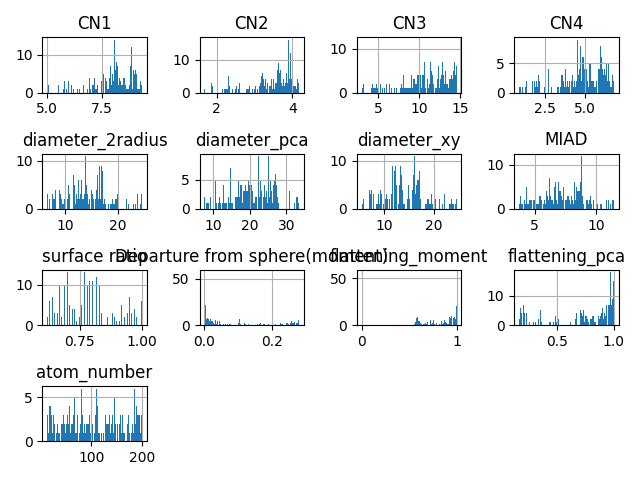

In [103]:
particles_descriptors=[]
bas=[]

for i in range(len(last_atom_list)):
    particles_descriptors.append(descriptor_table(ini_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

In [106]:
pdes

,CN1,CN2,CN3,CN4,diameter_2radius,diameter_pca,diameter_xy,MIAD,surface ratio,Departure from sphere(moment),flattening_moment,flattening_pca,atom_number
0,7.89,3.23,9.82,4.21,11.52,17.98,11.52,5.90,0.77,0.005054,0.00,0.97,57
1,6.67,2.52,6.37,2.15,9.13,11.60,9.13,4.78,0.89,0.107041,0.96,0.51,27
2,8.50,3.93,11.68,5.30,14.11,17.68,13.59,7.52,0.70,0.044427,0.78,0.67,111
3,7.15,2.61,7.82,2.79,9.07,12.84,9.07,4.96,0.88,0.019667,0.94,0.77,33
4,5.79,2.21,4.95,1.89,8.07,10.76,7.47,4.27,1.00,0.033119,0.00,0.97,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,8.23,3.89,10.65,5.08,24.52,33.20,24.52,11.41,0.79,0.280901,0.59,0.16,199
196,7.89,3.65,9.77,4.50,18.86,25.64,18.86,8.78,0.82,0.246046,0.59,0.22,113
197,8.97,3.77,13.68,6.11,15.85,25.50,15.85,8.09,0.71,0.003622,0.93,0.86,148
198,7.89,3.68,9.66,4.50,18.47,23.01,18.47,8.70,0.82,0.242912,0.58,0.25,111


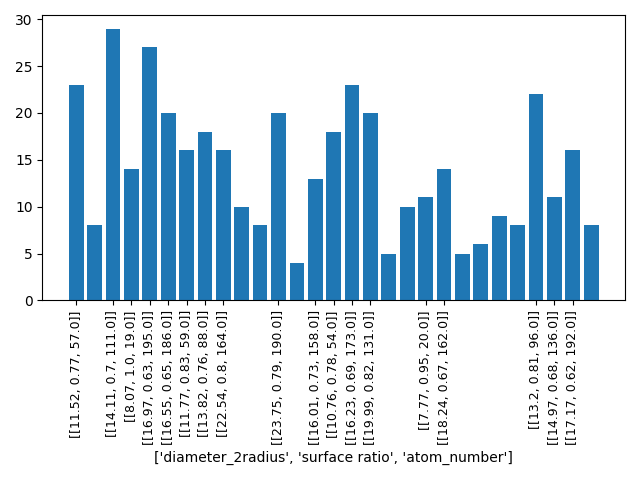

In [104]:
list_par=[]
descriptors=["diameter_2radius",
                "surface ratio",
                "atom_number"]

for i in range(pdes.shape[0]):
    dis=[]
    for d in descriptors:
        dis.append(pdes.iloc[i][d])
    list_par.append([dis])

par_dict={}
list_read=[]
for i in range(pdes.shape[0]):
    indices=np.where(np.isclose(list_par[i],list_par,rtol=1e-2).all(axis=1))[0]
    # print(indices)
    
    # print(list_read)
    if i not in list_read:
        list_read.extend(indices)
        par_dict[f"{list_par[i]}"]={"indices":indices,"num":len(indices)}


par_dict=pd.DataFrame(par_dict)
# print(par_dict)
i=0
index_get=[]
values=[]
for k,v in par_dict.items():
    if v['num']>10:
        values.append(k)
        index_get.append(i)
    i+=1

plt.figure()
plt.bar(np.arange(par_dict.shape[1]),par_dict.loc["num"])
plt.xlabel(descriptors)
plt.xticks(index_get,values,rotation=90,fontsize=9)  
plt.tight_layout()

In [77]:
# par_dict['[7.5, 2.95, 8.77, 3.41]']
view(last_atom_list[par_dict['[[11.21, 0.86, 42.0]]']['indices'][0]],viewer='x3d')

In [105]:
view(last_atom_list[198],viewer='x3d')

In [78]:
from shape_proj_util.geo_tools.convenient_datasoup import *
data=particle_database(element='Pt')
data.predefine_data(3.77)
table=data.shape_info().T



In [79]:
table

,CN1,CN2,CN3,CN4,diameter_2radius,diameter_pca,diameter_xy,MIAD,surface ratio,Departure from sphere(moment),flattening_moment,flattening_pca,atom_number
OCT_2,4.00,1.00,0.00,0.00,3.77,6.53,3.77,2.89,1.00,0.000000,1.00,1.00,6.0
OCT_3,6.32,1.89,5.05,1.89,7.54,13.06,7.54,4.16,0.95,0.000000,0.00,1.00,19.0
OCT_4,7.64,2.59,8.73,3.82,11.31,18.24,11.31,5.49,0.86,0.000000,1.00,1.00,44.0
OCT_5,8.47,3.11,11.29,5.22,15.08,25.96,15.08,6.84,0.78,0.000000,0.00,1.00,85.0
OCT_6,9.04,3.49,13.15,6.25,18.85,29.81,18.85,8.19,0.70,0.000000,1.00,1.00,146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
HEX_O1_2_SQ_O2_cut_ori_100_l_2,8.44,4.66,3.21,2.86,13.81,20.30,13.59,7.03,0.73,0.050589,0.77,0.57,91.0
HEX_O1_2_SQ_O2_cut_ori_100_l_3,7.89,4.11,3.06,2.57,14.26,19.68,13.59,6.70,0.81,0.109811,0.68,0.42,70.0
HEX_O1_2_SQ_O2_cut_ori_100_l_4,7.13,2.96,2.74,5.13,12.24,15.55,11.92,6.05,0.91,0.172209,0.61,0.35,46.0
HEX_O1_2_SQ_O2_cut_ori_100_l_5,5.76,2.88,2.08,3.84,11.39,11.47,11.31,5.30,1.00,0.244533,0.56,0.24,25.0


In [13]:
min(population, key=lambda x: calculate_similarity(x, individual))
# data.search_by_name("OCT_4")


array([ -1.32,  -0.7 ,  -3.68,  -1.93,  -3.77,  -5.18,  -3.77,  -1.33,
         0.09,   0.  ,  -1.  ,   0.  , -25.  ])